In [6]:
%pip install numpy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Equação da Reta: y = -43580.7431 + 280.6236 * x
Coeficiente de correlação (r) = 0.7020 *
Coeficiente de Determinação (R²) 0.4929


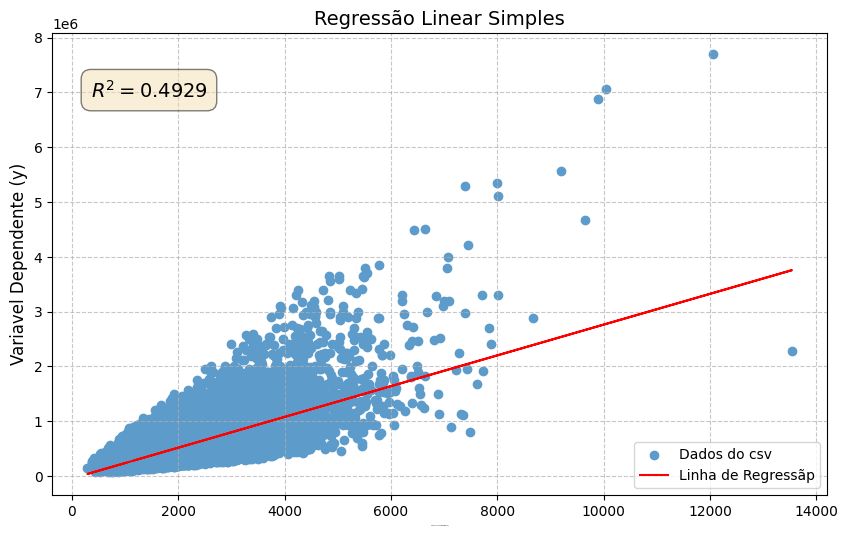

In [8]:
import numpy as np
import matplotlib.pyplot as plt

#1. Leitura dos dados do arquivo csv usando numpy
#Ignoramos a primeira linha (skip_header) pois ela contém os cabeça~hos x,y
dados = np.genfromtxt('kc_house_data.csv', delimiter= ',', skip_header=1, usecols=(5, 2))
x = dados[:, 0] #Variavel Idependente: sqft_living
y = dados[:, 1] # Variavel dependente : price
n = len(x) # quantide de amostra

#2 calculo dos somatorios necessarios para as formulas
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x**2)
sum_y2 = np.sum(y**2)

# 3. Calculo da Reta de regressão (y_hat = a + b*x)
#calculando o coeficiente  'b'
b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)

# Calculando o coeficiente 'a'
a = (sum_y - b * sum_x) /n

#Gerando os valores previstos (y_hat)
y_hat = a + b * x

#4. Calculo do coeficiente de correlação pearson (r)
numerador_r = n * sum_xy - (sum_x * sum_y)
denominador_r = np.sqrt(n * sum_x2 - sum_x**2) * np.sqrt(n * sum_y2 - sum_y**2)
r = numerador_r / denominador_r

# 5. Cálculo do coeficiente de determinação (R²)
y_mean = np.mean(y)
# Fórmula:  Somatorio de (y_hat - y_mean)² dividido pelo somatorio de (y - ymean)²
sq_reg = np.sum((y_hat - y_mean)**2)
sq_tot = np.sum((y -y_mean) **2)
r2 = sq_reg / sq_tot

#6 exibição dos resultados no console
print(f"Equação da Reta: y = {a:.4f} + {b:.4f} * x")
print(f"Coeficiente de correlação (r) = {r:.4f} *")
print(f"Coeficiente de Determinação (R²) {r2:.4f}")


#7. Visualização Gráfica dos dados
plt.figure(figsize=(10, 6))

#Gráfico de dispersão (Scatter plot) dos dados reais
plt.scatter (x, y, color = '#5D9BCA', label = 'Dados do csv')

plt.plot(x, y_hat, color = 'red', label='Linha de Regressãp')

#configuração de layout do grafico
plt.title('Regressão Linear Simples', fontsize=14)
plt.xlabel('Variavel Idependente (x)', fontsize=1)
plt.ylabel('Variavel Dependente (y)', fontsize=12)

#adiciona o valor de r² ao grafico para facil visualização
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes,
         fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round, pad=0.5', fc='wheat', alpha=0.5))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()




